# Phase 1 — Baseline Volatility Forecasts

This notebook evaluates three classical baselines for forecasting 5-day realized volatility:
- **Naive** — predict next week's vol = last week's vol
- **EWMA** — exponentially weighted moving average (span=32, ≈ RiskMetrics λ=0.94)
- **GARCH(1,1)** — parametric model fit on training data

All models are evaluated on identical walk-forward splits with a 5-day embargo gap to prevent leakage.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))

import matplotlib.pyplot as plt
import pandas as pd

from src.data.ingest import DEFAULT_RAW_DIR
from src.eval.evaluate import evaluate_baselines
from src.features.realized_vol import log_returns, realized_vol

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 4)

## 1. Load data

In [2]:
df = pd.read_parquet(DEFAULT_RAW_DIR / 'AAPL.parquet')
returns = log_returns(df['Adj Close']).dropna()

print(f"{len(returns)} trading days: {returns.index[0].date()} → {returns.index[-1].date()}")

11475 trading days: 1980-12-15 → 2026-06-26


## 2. Returns — volatility clustering

Large moves cluster together. This is the core statistical property that makes volatility forecastable.

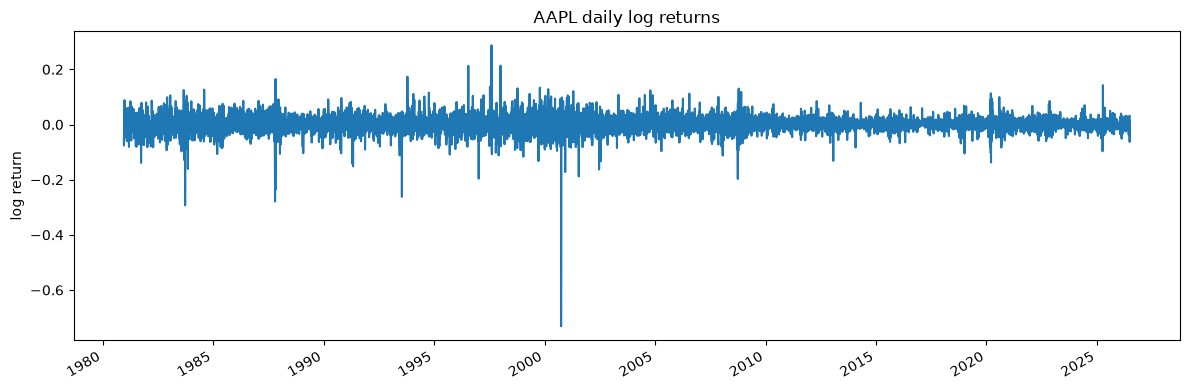

In [3]:
returns.plot(title='AAPL daily log returns', ylabel='log return', xlabel='')
plt.tight_layout()

## 3. Realized volatility — the target

5-day rolling realized vol (annualized). This is what each model is trying to predict one week ahead.

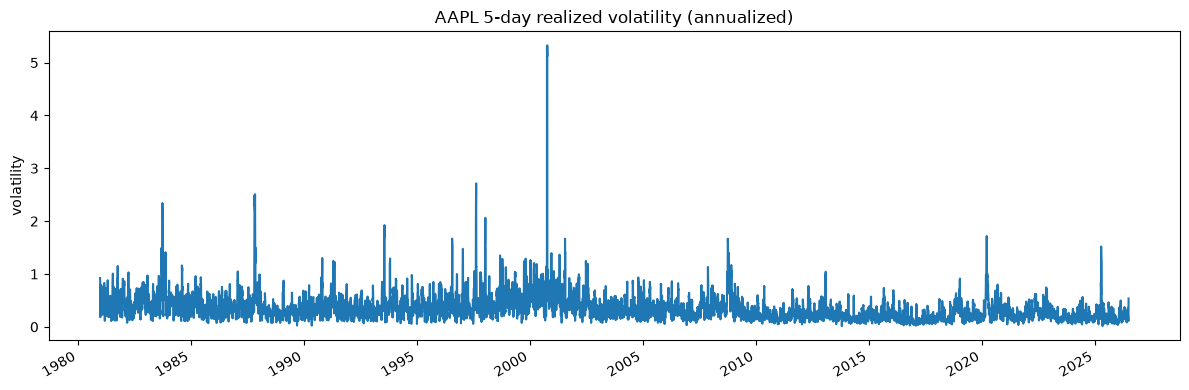

In [4]:
rv = realized_vol(returns, window=5)

rv.plot(title='AAPL 5-day realized volatility (annualized)', ylabel='volatility', xlabel='')
plt.tight_layout()

## 4. Walk-forward evaluation

5 expanding-window folds, minimum 252 days (1 year) of training data, 5-day embargo between train and test.

In [5]:
results = evaluate_baselines(returns, horizon=5, n_splits=5, min_train_size=252)
results.round(4)

,rmse,mae,qlike
naive,0.2570,0.1698,1.6150
ewma,0.2195,0.1508,0.5792
garch,0.2441,0.1892,0.6962


## 5. Results

**EWMA is the strongest classical baseline** — it beats both naive and GARCH on all three metrics. This is consistent with the literature: for equity daily vol, a fast-decaying exponential average often matches or beats parametric models at short horizons.

**GARCH beats naive on all three metrics** — the parametric model adds value over the simple rolling window, particularly on QLIKE where naive (1.615) is nearly 2.4× worse than GARCH (0.696). The deep learning model in Phase 2 will be benchmarked against these numbers on the same splits.